# Прогноз просрочки контрольного поручения

**Курсовой проект по курсу ML-Basic.**

**Что решаем.** Это задача **бинарной классификации**: по данным о поручении, известным в момент его постановки, предсказать одно из двух — будет оно **просрочено** или **выполнено в срок**. «Бинарная» — потому что ответов ровно два (0 или 1). Модель на исторических поручениях учится связывать входные признаки (кто, что, к какому сроку) с исходом (успели/не успели), а затем оценивает риск для новых поручений.

**Зачем это нужно.** Если ещё в момент постановки видно, что поручение с высокой вероятностью сорвётся, руководитель может вмешаться заранее: передвинуть срок, добавить людей, взять на особый контроль.

> ⚠️ **Данные синтетические.** Реальные данные организации в учебную работу не выносятся. Сгенерирован статистически правдоподобный набор (скрипт `generate_data.py`), повторяющий структуру, историчность и типичные дефекты («грязь») настоящего источника. Все ФИО заменены обезличенными псевдонимами вида `user_0001`.

## 1. Предметная область: что такое контрольное поручение

**Контрольное поручение** — это задача с контролем срока. В организации кто-то (автор/постановщик) ставит поручение: сформулирована тема, назначен ответственный исполнитель, задан **контрольный срок** (дедлайн). Дальше поручение проходит стадии («на исполнении» → возможные возвраты «на доработку» → «исполнено» / «просрочено»), и по нему может вестись переписка о ходе работ. Само это движение во времени (сколько раз возвращали, как долго висит) тоже несёт информацию — и его мы сможем использовать благодаря историчности данных.

Ключевые понятия, которыми мы оперируем:

- **Постановка** — момент создания поручения (`order_created_at`). Это точка, на которую мы делаем прогноз; обозначим её **T**.
- **Дедлайн** (`deadline`) — контрольный срок исполнения.
- **Исполнение** (`date_of_execution`) — когда поручение фактически закрыли (может отсутствовать, если ещё не закрыто).
- **Просрочка** — поручение исполнено **позже** дедлайна, либо срок уже прошёл, а оно всё ещё не исполнено. Это и есть наш **целевой признак** (`overdue`).

Логика проекта: **на момент T** мы знаем «условия задачи» (тип, тема, срок, состав участников), но ещё не знаем исхода. Модель должна по этим условиям оценить вероятность просрочки.

## 2. Подключение к базе данных

Данные лежат в **реляционной СУБД PostgreSQL**, запущенной локально в контейнере. «Реляционная» означает, что данные хранятся в связанных таблицах, а доступ к ним — через язык запросов **SQL**.

Из Python обращаемся к базе через драйвер **psycopg**: он отправляет SQL-запрос в базу и возвращает строки-результаты, которые мы складываем в таблицу `pandas.DataFrame` (удобный табличный объект для анализа).

В ячейке ниже — разовая настройка:
- **импорты** библиотек: `numpy`/`pandas` — работа с числами и таблицами, `matplotlib`/`seaborn` — графики, `psycopg` — связь с базой;
- `RS = 42` — «зерно» генератора случайности; фиксируем, чтобы результаты воспроизводились при каждом запуске одинаково;
- `AS_OF` — **дата среза**: момент, который мы считаем «сегодня» для этих данных. Он нужен, чтобы решить, просрочено ли ещё не закрытое поручение (если его срок раньше `AS_OF`, а оно не закрыто — значит, просрочено);
- `DSN` — строка подключения к базе (адрес, имя БД, логин/пароль учебного стенда);
- `read_sql(...)` — маленькая функция-помощник: открывает соединение, выполняет запрос, отдаёт `DataFrame`. Чтобы не повторять этот код в каждой ячейке.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RS = 42
AS_OF = pd.Timestamp("2026-08-02", tz="UTC")   # «сегодня» для этих данных (дата среза)

DSN = os.environ.get(
    "COURSEWORK_DSN",
    "host=127.0.0.1 port=5432 dbname=coursework user=ml password=ml_pw",
)

def read_sql(sql, params=None):
    """Выполнить SQL-запрос и вернуть результат в виде таблицы pandas."""
    with psycopg.connect(DSN) as con:
        cur = con.execute(sql, params)
        return pd.DataFrame(cur.fetchall(), columns=[d.name for d in cur.description])

**Проверка соединения.** Прежде чем что-либо анализировать, убедимся, что база доступна и в ней есть данные. Если базы нет (например, после перезагрузки компьютера контейнер остановлен), ячейка выдаст понятную ошибку с инструкцией, как поднять стенд и сгенерировать данные. Без этой проверки можно было бы «успешно» прогнать весь ноутбук по нулю строк и не заметить.

In [2]:
try:
    n = read_sql("select count(*) n from control_orders_v")["n"][0]
    obj = read_sql("select count(distinct order_bk) n from control_orders_v")["n"][0]
    print(f"Подключение OK. Строк-версий в таблице: {n}, уникальных поручений: {obj}")
    assert n > 0, "Таблица пуста"
except Exception as e:
    raise RuntimeError(
        "Нет данных или соединения. Подними контейнер и сгенерируй данные:\n"
        "  podman start coursework-pg\n"
        "  python generate_data.py"
    ) from e

Подключение OK. Строк-версий в таблице: 30829, уникальных поручений: 10000


## 3. Как устроена база данных

База — это упрощённая **витрина**: несколько связанных таблиц вокруг одной главной сущности (поручения). Такой подход называют «схемой звезда»: в центре — таблица-факт с поручениями, вокруг — таблицы-справочники, расшифровывающие ссылки.

Всего в базе шесть объектов:

| Объект | Что это | Роль |
|---|---|---|
| `control_orders_v` | **Факт с историей**: версии поручений (см. раздел про SCD2 ниже). Главная таблица. | из неё берём и признаки, и таргет |
| `control_order_types` | Справочник **типов** поручения (название по коду) | расшифровка `type_bk` |
| `users` | Справочник **пользователей** (обезличенные псевдонимы) | расшифровка ссылок на людей |
| `control_orders_user_roles_v` | «Мост»: участники поручения по ролям (одна строка = один человек в одной роли) | удобно считать состав команды |
| `control_order_progress_v` | Ход исполнения (комментарии по работе) — это **итоговая** информация | в признаки НЕ берём (утечка) |
| `control_orders` (**вьюха**) | «Текущий срез»: только актуальные версии, с подставленными именами вместо кодов | быстрый способ посмотреть «как сейчас» |

Посмотрим на реальный список таблиц прямо из базы (столбец `table_type`: `BASE TABLE` — таблица, `VIEW` — вьюха):

In [3]:
read_sql("""
    select table_name, table_type
    from information_schema.tables
    where table_schema = 'public'
    order by table_type, table_name
""")

,table_name,table_type
0,control_order_progress_v,BASE TABLE
1,control_order_types,BASE TABLE
2,control_orders_user_roles_v,BASE TABLE
3,control_orders_v,BASE TABLE
4,users,BASE TABLE
5,control_orders,VIEW


### Словарь полей главной таблицы `control_orders_v`

Каждая строка этой таблицы — **одна версия одного поручения** на некотором интервале времени. Поля делятся на четыре группы по роли в проекте:

| Поле | Тип | Смысл | Роль в модели |
|---|---|---|---|
| `order_bk` | UUID | **бизнес-ключ** поручения — один и тот же у всех версий одного поручения | ключ объекта |
| `control_order_type_bk` | UUID → `control_order_types` | тип поручения (ссылка на справочник) | **признак** (категориальный) |
| `control_order_theme` | TEXT | тема | **признак** |
| `description` | TEXT | описание | **признак** |
| `deadline` | TIMESTAMPTZ | контрольный срок | **признак** + нужен для таргета |
| `order_created_at` | TIMESTAMPTZ | дата постановки (**это наш момент T**) | опорная точка |
| `responsible_executor_bks` | UUID[] | ответственные исполнители (массив ссылок) | **признак** |
| `co_performers_bks` | UUID[] | соисполнители | **признак** |
| `participants_bks` | UUID[] | участники | **признак** |
| `task_author_bks` | UUID[] | авторы/постановщики | **признак** |
| `status` | TEXT | текущий статус | ⚠️ **итог** — утечка, в признаки нельзя |
| `is_done` | BOOL | исполнено ли | ⚠️ **итог** — утечка |
| `date_of_execution` | TIMESTAMPTZ | дата фактического исполнения | ⚠️ **итог** (нужен для таргета) |
| `days_expired` | TEXT | дней просрочки, считается «от сегодня» | ⚠️ **итог** — утечка, к тому же неконсистентная |
| `valid_period` | TSTZRANGE | **интервал действия версии** `[начало, конец)` | служебное (SCD2) |
| `is_current` | BOOL | это текущая (последняя) версия? | служебное (SCD2) |
| `closure_reason` | TEXT | почему версия закрыта (`changed`/`deleted`) | служебное (SCD2) |
| `deleted` | BOOL | мягкое удаление поручения | фильтр |
| `created_at`, `updated_at`, `created_by_bk` | | системные метки | не используем |

«**Итог**» (утечка / leakage) — это поля, которые становятся известны только ПОСЛЕ постановки и, по сути, уже содержат ответ. Если сунуть их в модель, она «угадает» ответ по ним — но на реальном прогнозе в момент T этих полей ещё нет. Поэтому они запрещены как признаки (во второй части покажем это численно).

Посмотрим на несколько реальных строк (ключевые поля):

In [4]:
read_sql("""
    select order_bk, control_order_type_bk, deadline, order_created_at,
           status, is_done, date_of_execution, valid_period, is_current
    from control_orders_v
    order by order_bk
    limit 5
""")

,order_bk,control_order_type_bk,deadline,order_created_at,status,is_done,date_of_execution,valid_period,is_current
0,000cd21a-65a7-4a30-b5b7-0dd9728f5897,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,2023-12-06 01:32:00+00:00,2023-08-08 01:32:00+00:00,На исполнении,False,None,"[2023-08-08 01:32:00+00:00, 2023-09-13 08:15:2...",False
1,000cd21a-65a7-4a30-b5b7-0dd9728f5897,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,2023-12-06 01:32:00+00:00,2023-08-08 01:32:00+00:00,На доработку,False,None,"[2023-09-13 08:15:27.141377+00:00, 2023-10-03 ...",False
2,000cd21a-65a7-4a30-b5b7-0dd9728f5897,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,2023-12-06 01:32:00+00:00,2023-08-08 01:32:00+00:00,На исполнении,False,None,"[2023-10-03 02:03:45.911956+00:00, 2023-10-08 ...",False
3,000cd21a-65a7-4a30-b5b7-0dd9728f5897,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,2023-12-06 01:32:00+00:00,2023-08-08 01:32:00+00:00,На доработку,False,None,"[2023-10-08 10:33:47.975807+00:00, 2023-10-12 ...",False
4,000cd21a-65a7-4a30-b5b7-0dd9728f5897,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,2023-12-06 01:32:00+00:00,2023-08-08 01:32:00+00:00,На исполнении,False,None,"[2023-10-12 03:37:54.985860+00:00, 2023-10-14 ...",False


## 4. Историчность данных (SCD2) — на пальцах

Обычная база хранит только «последнее состояние» объекта. Здесь иначе: хранится **вся история изменений**. Такой приём называется **SCD2** (Slowly Changing Dimension type 2).

**Как это работает, на примере.** Поставили поручение «Подготовить отчёт» 1 марта. В таблице появляется строка — *версия 1* с интервалом действия `[1 марта, ∞)` (открыт справа = «действует до сих пор»). 10 марта статус сменился на «на исполнении»: *версия 1* **закрывается** — её интервал становится `[1 марта, 10 марта)`, — и добавляется *версия 2* с `[10 марта, ∞)`. И так при каждом изменении.

Важные детали:
- У всех версий одного поручения **один и тот же** `order_bk` (бизнес-ключ = «номер самого поручения»), но **разные** `version_id` (номер конкретного снимка).
- `valid_period` — интервал, когда версия была актуальна. По нему всегда можно спросить: «а каким поручение было на дату X?».
- У **последней** версии интервал открыт справа, и `is_current = true`.
- База гарантирует, что интервалы версий одного поручения **не пересекаются** (специальный констрейнт) — то есть в любой момент времени действует не более одной версии (у снятых с контроля после закрытия — ни одной).

**Зачем это нам.** Если взять просто «последнее состояние», в нём уже стоит итог (`status = 'Просрочено'`) — а в момент прогноза мы его не знали. SCD2 позволяет восстановить состояние поручения **на момент постановки** и честно отделить «что было известно на входе» от «чем всё закончилось».

Ниже — реальная история одного поручения (берём такое, у которого накопилось ≥ 3 версий):

In [5]:
sample_bk = read_sql(
    "select order_bk from control_orders_v group by order_bk "
    "having count(*) >= 3 order by order_bk limit 1")["order_bk"][0]

read_sql("""
    select lower(valid_period) as version_start,   -- начало версии
           upper(valid_period) as version_end,     -- конец (NaT = ещё действует)
           closure_reason, status, is_done, date_of_execution
    from control_orders_v
    where order_bk = %s
    order by lower(valid_period)
""", (sample_bk,))

,version_start,version_end,closure_reason,status,is_done,date_of_execution
0,2023-08-08 01:32:00+00:00,2023-09-13 08:15:27.141377+00:00,changed,На исполнении,False,NaT
1,2023-09-13 08:15:27.141377+00:00,2023-10-03 02:03:45.911956+00:00,changed,На доработку,False,NaT
2,2023-10-03 02:03:45.911956+00:00,2023-10-08 10:33:47.975807+00:00,changed,На исполнении,False,NaT
3,2023-10-08 10:33:47.975807+00:00,2023-10-12 03:37:54.985860+00:00,changed,На доработку,False,NaT
4,2023-10-12 03:37:54.985860+00:00,2023-10-14 19:32:00+00:00,changed,На исполнении,False,NaT
5,2023-10-14 19:32:00+00:00,NaT,NaN,Исполнено в срок,True,2023-10-14 19:32:00+00:00


Как читать таблицу выше: строки идут по времени. У ранних версий заполнен `version_end` и указана причина закрытия (`changed` — поле изменилось), а у последней `version_end = NaT` — она открыта, то есть **текущая**. Статус меняется от рабочего к финальному. Вот эту «эволюцию во времени» мы и используем.

### Ссылки и справочники (почему в данных коды, а не имена)

В таблице-факте лежат не тексты, а **ссылки-коды (UUID)**. Например, тип поручения хранится как `control_order_type_bk`, а его название («Поручение Мэра» и т.п.) — в отдельном справочнике `control_order_types`. Чтобы получить название, таблицы **соединяют** (`JOIN`) по коду. Так сделано, чтобы не дублировать текст и легко его менять в одном месте.

Ссылки на людей (`responsible_executor_bks` и т.п.) — это **массивы** кодов (у поручения может быть несколько исполнителей), которые расшифровываются через справочник `users`.

Есть готовая вьюха `control_orders` — «текущий срез»: она сама отбирает только актуальные версии и подставляет имена вместо кодов, удобно для взгляда «как сейчас». Но для честной сборки «на момент T» нам нужна именно **история версий**, поэтому дальше мы работаем с `control_orders_v` напрямую.

## 5. Сборка обучающей выборки «на момент T» (без утечки будущего)

Это центральный методический приём проекта. Собираем таблицу, где одна строка = одно поручение, и в ней:
- **признаки** — из **первой версии** (состояние на момент постановки T): тип, тема, описание, дедлайн, состав участников;
- **таргет** `overdue` — из **итога** (последняя версия): просрочено или нет.

SQL-запрос ниже использует две конструкции `distinct on (order_bk)` (особенность PostgreSQL: «взять по одной строке на каждый `order_bk`»):
- `firstv` — сортируем версии по началу интервала **по возрастанию** и берём первую → это состояние на T;
- `curv` — сортируем **по убыванию** и берём первую → это последняя (итоговая) версия.

Затем соединяем их по `order_bk`. Удалённые поручения (`deleted`) отбрасываем. Итоговые поля (`status`, `is_done`, ...) тащим **только** для построения таргета и будущей демонстрации утечки — как признаки они использоваться не будут.

In [6]:
raw = read_sql("""
    with firstv as (           -- первая версия = состояние на момент T
      select distinct on (order_bk)
        order_bk, control_order_type_bk, control_order_theme, description,
        deadline, order_created_at,
        responsible_executor_bks, co_performers_bks, participants_bks, task_author_bks
      from control_orders_v
      order by order_bk, lower(valid_period) asc),
    curv as (                  -- ПОСЛЕДНЯЯ версия каждого поручения = итог
      select distinct on (order_bk)
        order_bk, is_done, date_of_execution, status, days_expired, deleted
      from control_orders_v
      order by order_bk, lower(valid_period) desc)
    select f.*, c.is_done, c.date_of_execution, c.status, c.days_expired
    from firstv f join curv c using(order_bk)
    where not c.deleted        -- удалённые поручения не рассматриваем
""")
print("Неудалённых поручений:", len(raw))
raw = raw[raw["deadline"].notna()].copy()  # без дедлайна просрочки нет (всегда 0)
print("После отсева поручений без дедлайна:", len(raw))

Неудалённых поручений: 9805
После отсева поручений без дедлайна: 9506


### Проверка: «состояние на момент T» действительно без исхода

Карточные поля мы берём из **первой** версии (состояние на постановку), а исход — из **последней** (и только для метки). Убедимся, что это честно: у **каждого** поручения версия, действующая сразу после постановки (`order_created_at + 1 секунда`), не несёт исхода — `is_done = false`, а `date_of_execution` пусто. Если бы часть поручений имела единственную версию, покрывающую и постановку, и итог (частая ловушка наивного среза «текущее состояние через `valid_period @> T`»), в признак «на момент T» затекло бы будущее.

In [7]:
viol = read_sql("""
    select count(*) as n
    from control_orders_v
    where valid_period @> (order_created_at + interval '1 second')
      and (is_done is true or date_of_execution is not null)
""")["n"][0]
total = read_sql("select count(distinct order_bk) n from control_orders_v")["n"][0]
print(f"Версий 'на момент T' с уже проставленным исходом: {int(viol)} из {int(total)} "
      f"поручений — ожидаем 0.")
assert int(viol) == 0, "Инвариант историчности нарушен: в состояние на T попал исход!"

Версий 'на момент T' с уже проставленным исходом: 0 из 10000 поручений — ожидаем 0.


### Построение целевого признака `overdue`

Метку «просрочено» выводим **из дат исхода**, а не из текстового статуса (статус считаем «подсказкой из будущего» и позже используем только для проверки). Правило простое:
- поручение **исполнено** (`date_of_execution` заполнена) → просрочено, если исполнили **позже** дедлайна;
- поручение **не исполнено** → просрочено, если к дате среза `AS_OF` срок уже прошёл;
- незакрытые поручения, чей срок ещё **не наступил** на дату среза, имеют нерешённый исход — их **исключаем** (иначе пометили бы «в срок» авансом; таких 41, все попадают в тестовый период).

⚠️ **Ловушка pandas.** Пустая дата в pandas — это специальное значение `NaT` (Not-a-Time), а не `None`. Проверка `date_of_execution is not None` для `NaT` вернёт `True` и уведёт в неверную ветку (`NaT > deadline` → всегда `False`), из-за чего все ещё не исполненные поручения ошибочно получат метку 0. Поэтому проверяем через `pd.notna(...)`. (Это реальная ошибка, на которой легко «потерять» треть просрочек, поэтому она вынесена в комментарий.)

После построения метки печатаем сводку «статус → доля просрочек». Это **контроль качества**: каждый статус должен однозначно отображаться в 0 или 1 (без «размазывания»), иначе где-то ошибка в логике.

In [8]:
def is_overdue(r):
    if pd.notna(r["date_of_execution"]):
        return int(r["date_of_execution"] > r["deadline"])  # исполнено позже срока
    return int((not bool(r["is_done"])) and (r["deadline"] < AS_OF))  # срок прошёл

raw["overdue"] = raw.apply(is_overdue, axis=1)

# Цензурирование: у незакрытых поручений, чей срок ещё НЕ наступил на дату среза,
# исход не решён (могут ещё стать просрочкой). Помечать их «в срок» — значит угадывать
# наперёд, поэтому исключаем их из выборки.
censored = ((~raw["is_done"].astype(bool)) & raw["date_of_execution"].isna()
            & (raw["deadline"] >= AS_OF))
print(f"Исключено цензурированных (срок ещё не наступил): {int(censored.sum())}")
raw = raw[~censored].copy()

print(f"Доля просроченных: {raw['overdue'].mean():.3f}")
# контроль: каждый статус должен давать 0 или 1 без размазывания
print(raw.groupby("status")["overdue"].agg(["mean", "size"]).round(3).to_string())

Исключено цензурированных (срок ещё не наступил): 41


Доля просроченных: 0.307
                              mean  size
status                                  
Исполнено в срок               0.0  6558
Исполнено с нарушением срока   1.0  2853
Просрочено                     1.0    54


Доля просрочек ≈ 0.30 — умеренный **дисбаланс классов** (просрочек меньше, чем выполненных в срок). Каждый оставшийся статус отобразился ровно в одно значение метки: «в срок» → 0, «с нарушением срока»/«просрочено» → 1 (незакрытые с ещё не наступившим сроком исключены как цензурированные). Значит, таргет согласован с исходом и логика верна.

## 6. Инженерия признаков на момент T

**Инженерия признаков** — это превращение «сырых» полей в числа/категории, понятные модели. Берём только то, что известно на момент постановки:

- `slack_days` — **запас времени** в днях от постановки до дедлайна (`deadline − order_created_at`). Ожидаемо главный драйвер: меньше запас → выше риск;
- `desc_len`, `desc_missing` — длина описания и флаг его отсутствия (плохо описанные поручения рискованнее);
- `theme_len` — длина темы;
- `n_co_performers`, `n_participants`, `n_authors` — размер команды (больше людей → сложнее координация). **Важный нюанс:** «нет участников» в источнике встречается в двух формах — как `NULL` и как пустой массив `{}`; обе приводим к 0;
- временные признаки постановки: день недели (`dow`), день месяца, флаги «пятница» и «конец месяца» (в конце периодов нагрузка выше);
- `executor` — код ответственного исполнителя (понадобится во второй части, чтобы закодировать его историческую дисциплину).

In [9]:
def arr_len(v):
    return 0 if v is None else len(v)          # NULL и пустой массив {} → 0 участников

df = raw.copy()
df["slack_days"] = (df["deadline"] - df["order_created_at"]).dt.total_seconds() / 86400
df["desc_len"] = df["description"].fillna("").str.len()
df["desc_missing"] = df["description"].isna().astype(int)
df["theme_len"] = df["control_order_theme"].fillna("").str.len()
df["n_co_performers"] = df["co_performers_bks"].apply(arr_len)
df["n_participants"] = df["participants_bks"].apply(arr_len)
df["n_authors"] = df["task_author_bks"].apply(arr_len)
df["dow"] = df["order_created_at"].dt.weekday          # 0=пн .. 6=вс
df["is_friday"] = (df["dow"] == 4).astype(int)
df["day_of_month"] = df["order_created_at"].dt.day
df["is_month_end"] = (df["day_of_month"] >= 25).astype(int)
df["executor"] = df["responsible_executor_bks"].apply(
    lambda v: str(v[0]) if v else "NONE")

feature_num = ["slack_days", "desc_len", "theme_len", "n_co_performers",
               "n_participants", "n_authors", "dow", "day_of_month",
               "is_friday", "is_month_end", "desc_missing"]
df[feature_num + ["control_order_type_bk", "executor", "overdue"]].head()

,slack_days,desc_len,theme_len,n_co_performers,n_participants,n_authors,dow,day_of_month,is_friday,is_month_end,desc_missing,control_order_type_bk,executor,overdue
0,120.0,0,40,0,1,1,1,8,0,0,1,dfed2c43-e256-46dc-8f54-86b7c7b5b2bc,7c967f79-b7e9-4aca-a970-65e18e46d534,0
1,14.0,172,37,3,0,1,4,18,1,0,0,8d7248e2-951f-48d0-9e84-f058d5a804eb,beb79919-3f22-4af8-a3be-d01d43cf2fde,1
2,17.0,173,43,4,2,1,0,3,0,0,0,0ab54bde-20a0-4502-ae06-809725e97977,2a45c2ab-8cbf-4db0-b264-accc79ac1b1e,0
3,7.0,168,40,2,0,1,6,18,0,0,0,5a8aaeca-1a50-4ec3-aabc-25fa3fe12e47,5cec4eb5-edd9-4831-9ca3-5cfb04fc6d82,1
4,44.0,229,46,1,2,1,0,8,0,0,0,093923de-8bab-4e3b-a628-6bfbe767dcea,81f76d1c-2dbc-4134-830f-f46e8026695f,0


## 6.5. Признак из историчности: нагрузка исполнителя на момент T

До сих пор признаки брались из карточки одного поручения. Но историчность (SCD2) позволяет посчитать **контекст на момент T** — величины, зависящие от других поручений и их движения во времени. Главный из них — **текущая загрузка исполнителя**: сколько других его поручений **ещё не закрыто** к моменту T.

Поручение перестаёт нагружать исполнителя в момент `close_time`:
- **исполнено** → в момент `date_of_execution`;
- **снято с контроля** → в момент снятия (начало снятой версии);
- иначе (**всё ещё открыто** на дату среза) → не закрыто вовсе (`close_time` нет).

На момент T «висящими» считаем поручения того же исполнителя, созданные **раньше** T, у которых `close_time` ещё не наступил (или его нет). Признак честный — использует только **прошлое** относительно T. Ожидаем: больше параллельная нагрузка → выше риск просрочки.

Вторую характеристику из историчности — **историческую дисциплину исполнителя** (долю его прошлых просрочек) — посчитаем при обучении (раздел 9), строго по прошлым поручениям, чтобы не занести утечку.

In [10]:
workload = read_sql("""
    with base as (
      select distinct on (order_bk)
        order_bk, order_created_at, responsible_executor_bks[1] as executor_bk
      from control_orders_v order by order_bk, lower(valid_period)),
    outcome as (
      select distinct on (order_bk) order_bk, is_done, date_of_execution, deleted
      from control_orders_v order by order_bk, lower(valid_period) desc),
    removal as (             -- момент снятия с контроля = начало снятой версии
      select order_bk, lower(valid_period) as removal_time
      from control_orders_v where deleted),
    closed as (              -- close_time: когда поручение вышло из активной нагрузки
      select b.order_bk, b.order_created_at, b.executor_bk,
             case when o.is_done then o.date_of_execution
                  when o.deleted then r.removal_time
                  else null end as close_time
      from base b join outcome o using(order_bk)
      left join removal r using(order_bk))
    select a.order_bk,
           count(*) filter (
             where c.order_created_at < a.order_created_at
               and (c.close_time is null or c.close_time > a.order_created_at)
           ) as workload_at_t
    from closed a
    join closed c on c.executor_bk = a.executor_bk and c.order_bk <> a.order_bk
    group by a.order_bk
""")
df = df.merge(workload, on="order_bk", how="left")
df["workload_at_t"] = df["workload_at_t"].fillna(0)  # естественно ограничен (max ~11)

by_load = df.groupby(df["workload_at_t"].clip(upper=4))["overdue"].agg(["mean", "size"])
by_load.index = ["0", "1", "2", "3", "4+"]
print("Доля просрочек по нагрузке исполнителя на момент T:")
print(by_load.round(3).to_string())

Доля просрочек по нагрузке исполнителя на момент T:
     mean  size
0   0.107  2183
1   0.199  2774
2   0.335  2117
3   0.481  1202
4+  0.701  1189


## 7. Разведочный анализ (EDA)

**EDA (exploratory data analysis)** — «посмотреть на данные глазами» перед моделированием: понять баланс классов, увидеть, какие признаки связаны с исходом, и оценить качество данных.

### 7.1. Баланс классов

Смотрим соотношение «в срок / просрочено». Это определяет выбор метрик: при дисбалансе обычная **accuracy** (доля правильных ответов) обманчива — модель, которая всегда говорит «в срок», уже будет права в ~70% случаев, но как предсказатель просрочек она бесполезна. Поэтому во второй части опираемся на precision/recall/F1 и ROC-AUC.

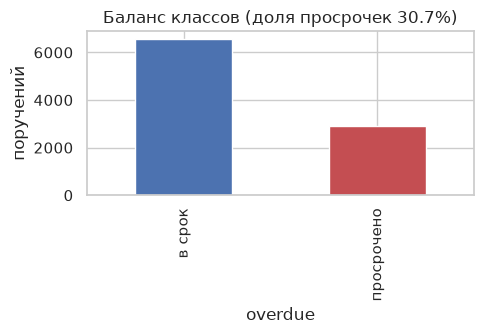

In [11]:
ax = df["overdue"].map({0: "в срок", 1: "просрочено"}).value_counts().plot(
    kind="bar", color=["#4c72b0", "#c44e52"], figsize=(5, 3.5))
ax.set_title(f"Баланс классов (доля просрочек {df['overdue'].mean() * 100:.1f}%)")
ax.set_ylabel("поручений")
plt.tight_layout()
plt.show()

### 7.2. Ключевые признаки в разрезе исхода

**Boxplot** («ящик с усами») показывает распределение признака: линия внутри ящика — медиана (типичное значение), сам ящик — средние 50 % значений (от 25-го до 75-го процентиля), усы — почти весь остальной размах. Строим по ящику на каждый класс: если ящики «в срок» и «просрочено» заметно разъезжаются по высоте — признак несёт сигнал. Берём три признака, у которых разделение ожидается: **запас времени**, **длину описания** и **нагрузку исполнителя на момент T**. По горизонтали — класс исхода (не число), по вертикали — значение признака в своих единицах (дни / символы / штуки).

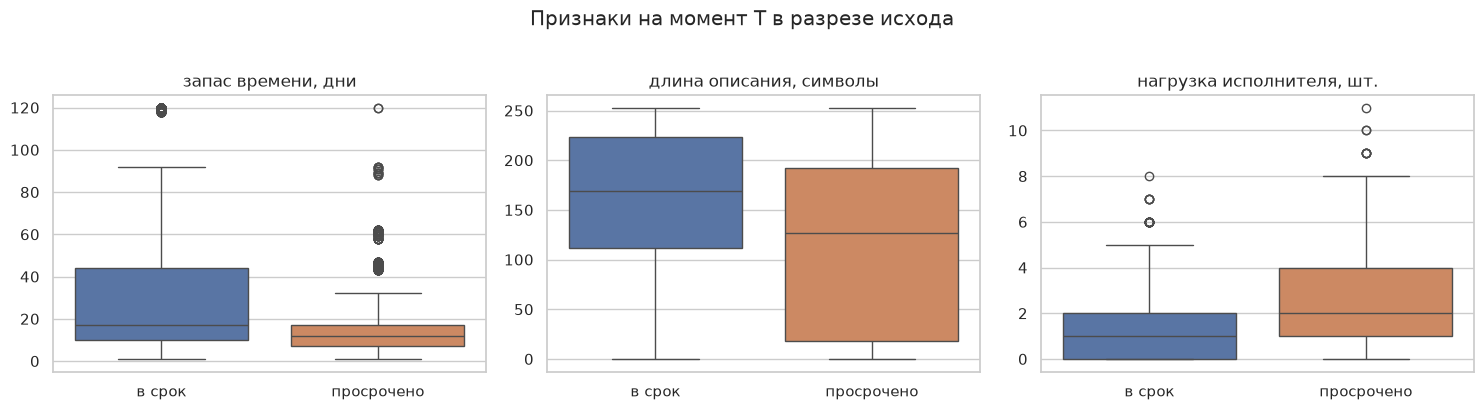

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [("slack_days", "запас времени, дни"),
          ("desc_len", "длина описания, символы"),
          ("workload_at_t", "нагрузка исполнителя, шт.")]
for ax, (col, title) in zip(axes, panels):
    sns.boxplot(data=df, x="overdue", y=col, hue="overdue", legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["в срок", "просрочено"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Признаки на момент T в разрезе исхода", y=1.02)
plt.tight_layout()
plt.show()

Все три ящика «просрочено» смещены относительно «в срок» — признаки разделяют классы:
- **запас времени**: у просроченных заметно меньше (медиана ≈ 12 дней против ≈ 17, и ящик ниже и уже) — это главный и самый логичный драйвер;
- **длина описания**: у просроченных описания короче и разнообразнее (ящик тянется к малым значениям) — плохо описанные поручения рискованнее;
- **нагрузка исполнителя**: у просроченных выше (медиана 2 против 1, ящик 1–4 против 0–2) — перегруженный исполнитель чаще не успевает.

Все три величины известны уже в момент постановки — именно на них и должна опираться модель. (Число соисполнителей мы тоже пробовали, но на «ящиках» оно почти не разделяет классы — эффект слабый и виден лишь в среднем; сильных признаков и без него достаточно.)

### 7.3. Доля просрочек по типу поручения

Разные типы поручений могут срываться с разной частотой. Считаем долю просрочек внутри каждого типа — это подскажет, полезен ли признак «тип». Тип хранится ссылкой (`type_bk`), поэтому подтягиваем название из справочника `control_order_types` через `JOIN`.

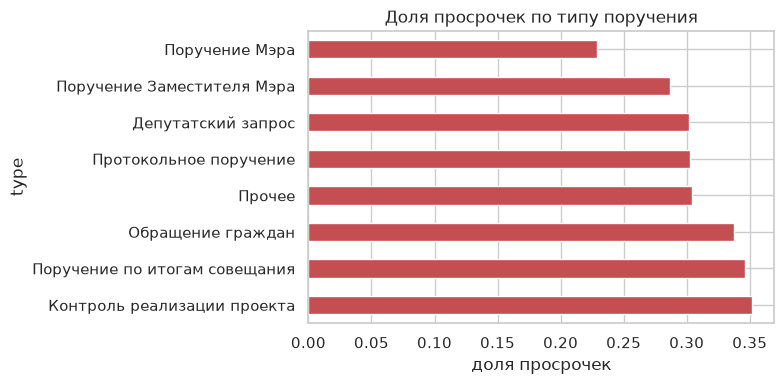

,mean,size
type,,
Контроль реализации проекта,0.352,1166
Поручение по итогам совещания,0.346,1245
Обращение граждан,0.337,1127
Прочее,0.304,1198
Протокольное поручение,0.303,1169
Депутатский запрос,0.302,1162
Поручение Заместителя Мэра,0.287,1178
Поручение Мэра,0.229,1220


In [13]:
by_type = read_sql(
    "select elma_id as control_order_type_bk, name as type "
    "from control_order_types")
rate = (df.merge(by_type, on="control_order_type_bk", how="left")
          .groupby("type")["overdue"].agg(["mean", "size"])
          .sort_values("mean", ascending=False))
ax = rate["mean"].plot(kind="barh", figsize=(8, 4), color="#c44e52")
ax.set_title("Доля просрочек по типу поручения")
ax.set_xlabel("доля просрочек")
plt.tight_layout()
plt.show()
rate.round(3)

### 7.4. Обзор пропусков и «грязи» в данных

Реальные витрины неаккуратны, и синтетика это воспроизводит. Проверяем долю пропусков в описании и — отдельно — как в данных представлено «нет участников»: как `NULL` и как пустой массив `{}`. Это две формы одного смысла, и в инженерии признаков мы обе привели к 0. Знать про такие вещи важно, чтобы препроцессинг не сломался на пропусках.

In [14]:
print(f"NULL description: {df['desc_missing'].mean() * 100:.1f}%")
for col in ["co_performers_bks", "participants_bks"]:
    isnull = raw[col].isna().mean() * 100
    empty = raw[col].apply(lambda x: x is not None and len(x) == 0).mean() * 100
    print(f"{col}: NULL {isnull:.1f}%  пустой {{}} {empty:.1f}%  (обе формы = 0)")

NULL description: 7.2%
co_performers_bks: NULL 14.6%  пустой {} 15.3%  (обе формы = 0)
participants_bks: NULL 22.6%  пустой {} 22.2%  (обе формы = 0)


## Итоги первой части

- Разобрались с **предметной областью** (контрольные поручения, что такое просрочка) и **устройством базы** (таблицы, словарь полей, историчность SCD2).
- Собрали обучающую выборку **«на момент T»**: признаки — из состояния на постановку, таргет — из исхода. Утечки будущего в признаки нет by design, и это подтверждено явной проверкой инварианта (это и есть главный методический результат первой части).
- **Историчность не просто хранится, а работает на прогноз:** из истории версий построен признак **нагрузки исполнителя на момент T** — по группам нагрузки доля просрочек монотонно растёт с ~0.11 до ~0.70.
- Классы: ~30% просрочек — умеренный дисбаланс; метрики во второй части трактуем с приоритетом **recall** по классу «просрочено».
- Легитимные драйверы риска видны уже в EDA: малый запас времени, число соисполнителей, тип поручения, нагрузка исполнителя.
- «Грязь» источника воспроизведена и учтена: пропуски в описании/дедлайне, `NULL` vs пустой массив у участников.

**Во второй части:** численная демонстрация утечки (поля-итоги дают AUC ≈ 1.0 — и почему их нельзя брать в признаки), добавление **исторической дисциплины исполнителя** (as-of), обучение моделей (логистическая регрессия + kNN), метрики, ROC-кривые, интерпретация коэффициентов и вывод, какая модель лучше.

# Часть 2. Моделирование

В первой части мы собрали честную выборку «на момент T». Теперь: (1) численно покажем, почему поля-итоги нельзя брать в признаки; (2) обучим две модели курса — логистическую регрессию и kNN; (3) сравним их, интерпретируем и ответим, какая лучше.

## 8. Демонстрация утечки данных (data leakage)

**Утечка** — это когда в признаки случайно попадает информация, которой в реальный момент прогноза ещё нет. Модель тогда показывает «отличное» качество на тесте, но в бою бесполезна, потому что таких признаков там не будет.

У нас кандидаты на утечку — поля-итоги: `status`, `is_done`, `days_expired`. Они заполняются уже ПОСЛЕ постановки и, по сути, содержат ответ («Просрочено» и т.п.). Обучим на них логистическую регрессию и посмотрим на ROC-AUC (метрика качества ранжирования, 0.5 — случайно, 1.0 — идеально).

Ниже — тот же разбитый по времени набор (см. следующий раздел про сплит), но признаки — только «итоговые».

In [15]:
# сплит по времени (подробно разбираем в разделе 9); здесь нужен, чтобы честно замерить
_d = df.sort_values("order_created_at").reset_index(drop=True)
_cut = int(len(_d) * 0.7)
_tr, _te = _d.iloc[:_cut].copy(), _d.iloc[_cut:].copy()

for part in (_tr, _te):                      # готовим ИТОГОВЫЕ поля как признаки
    part["days_expired_num"] = (
        pd.to_numeric(part["days_expired"], errors="coerce").fillna(0))
    part["is_done_int"] = part["is_done"].astype("Int64").fillna(0).astype(int)

leak_pre = ColumnTransformer([
    ("num", StandardScaler(), ["days_expired_num", "is_done_int"]),
    ("status", OneHotEncoder(handle_unknown="ignore"), ["status"]),
])
leak_model = Pipeline([("pre", leak_pre), ("lr", LogisticRegression(max_iter=1000))])
leak_cols = ["days_expired_num", "is_done_int", "status"]
leak_model.fit(_tr[leak_cols], _tr["overdue"])
leak_proba = leak_model.predict_proba(_te[leak_cols])[:, 1]
leak_auc = roc_auc_score(_te["overdue"], leak_proba)
print(f"ROC-AUC на ПОЛЯХ-ИТОГАХ: {leak_auc:.3f}")

# один только status уже разделяет классы идеально
status_pre = ColumnTransformer(
    [("s", OneHotEncoder(handle_unknown="ignore"), ["status"])])
status_only = Pipeline([("pre", status_pre), ("lr", LogisticRegression(max_iter=1000))])
status_only.fit(_tr[["status"]], _tr["overdue"])
status_auc = roc_auc_score(
    _te["overdue"], status_only.predict_proba(_te[["status"]])[:, 1])
print(f"ROC-AUC только по одному status: {status_auc:.3f}")

ROC-AUC на ПОЛЯХ-ИТОГАХ: 1.000
ROC-AUC только по одному status: 1.000


AUC = 1.0 — идеально: и полный набор полей-итогов, и даже один только `status` разделяют классы безошибочно. Но это **не успех, а тревожный сигнал**: столь высокое качество означает, что признаки фактически содержат ответ. В реальном прогнозе в момент постановки этих полей ещё нет, поэтому такая модель — самообман. **Вывод:** `status`, `is_done`, `date_of_execution`, `days_expired` исключаем из признаков. Дальше используем только то, что известно на момент T.

## 9. Подготовка данных к обучению

**Разбиение на train/test — по времени, а не случайно.** Данные упорядочены во времени (даты постановки 2023–2026). Если бы мы делили случайно, в обучение попали бы поручения из «будущего» относительно тестовых — скрытая утечка. Поэтому сортируем по `order_created_at` и берём первые 70% в обучение, последние 30% — в тест. Это честно имитирует ситуацию «учимся на прошлом, прогнозируем будущее».

**Про разницу долей просрочек train/test.** Ниже увидим ~0.29 на train против ~0.34 на тесте. Это не поломка сплита, а **разгон системы из пустого состояния**: в начале 2023 у исполнителей ещё мало параллельных поручений, нагрузка (и с ней доля просрочек) нарастает и выходит на плато к 2025 — тестовое окно (середина 2025 — середина 2026) уже стационарно. Модель это переносит: признаки one-hot/масштаб не завязаны на абсолютный год.

**Историческая дисциплина исполнителя (`exec_hist`).** Идентификатор исполнителя — категория со 150 значениями; напрямую в модель её не подать. Кодируем исполнителя его **исторической долей просрочек, посчитанной строго по прошлому**: для каждого train-поручения — среднее по его же **более ранним** train-поручениям (расширяющееся среднее, `as-of` — без подглядывания в текущий и будущие исходы); для теста — зафиксированное train-среднее исполнителя, а незнакомым — общее train-среднее. Это тот самый признак «из историчности», что и нагрузка: доступен уже в момент T.

**Оговорка о честности CV.** `exec_hist` и `workload_at_t` считаем один раз (по train / по прошлому), а не заново внутри каждого фолда кросс-валидации; плюс сама CV перемешивает train без учёта времени. Поэтому CV-оценки при подборе `C`/`k` слегка оптимистичны — но на финальную оценку по отложенному **тесту** это не влияет (тест в подборе не участвует).

**Препроцессинг** соберём в `ColumnTransformer`: числовые признаки — `StandardScaler` (общий масштаб, критично для kNN и полезно логрегу), тип поручения — `OneHotEncoder`. Скейлер и кодировщик обучаются внутри пайплайна только на train.

In [16]:
# --- сплит по времени ---
data = df.sort_values("order_created_at").reset_index(drop=True)
cut = int(len(data) * 0.7)
train, test = data.iloc[:cut].copy(), data.iloc[cut:].copy()
print(f"train: {len(train)}  test: {len(test)}")
print(f"граница по времени: {train['order_created_at'].max().date()} | доля просрочек "
      f"train {train['overdue'].mean():.3f}, test {test['overdue'].mean():.3f}")

# --- историческая дисциплина исполнителя (as-of, только прошлые поручения) ---
# на train — расширяющееся среднее просрочек ТОЛЬКО по более ранним поручениям того
# же исполнителя (без подглядывания в текущий и будущие исходы); на test — фиксированное
# train-среднее исполнителя (незнакомый исполнитель -> общее train-среднее).
global_rate = train["overdue"].mean()
exec_hist = np.zeros(len(data))
s, c = {}, {}
for i in range(len(data)):
    u = data.at[i, "executor"]
    exec_hist[i] = s[u] / c[u] if c.get(u, 0) > 0 else global_rate
    if i < cut:                       # историю копим только по train
        s[u] = s.get(u, 0.0) + data.at[i, "overdue"]
        c[u] = c.get(u, 0) + 1
data["exec_hist"] = exec_hist
train, test = data.iloc[:cut].copy(), data.iloc[cut:].copy()

# --- итоговый набор признаков (только известное на момент T) ---
# feature_num — карточные признаки; exec_hist и workload_at_t — из историчности.
NUM = feature_num + ["exec_hist", "workload_at_t"]
CAT = ["control_order_type_bk"]
X_train, y_train = train[NUM + CAT], train["overdue"]
X_test, y_test = test[NUM + CAT], test["overdue"]

def make_pre():
    return ColumnTransformer([("num", StandardScaler(), NUM),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

def evaluate(name, estimator):
    """Метрики бинарной классификации на тесте (положительный класс — «просрочено»)."""
    pred = estimator.predict(X_test)
    proba = estimator.predict_proba(X_test)[:, 1]
    return {"model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba)}

train: 6625  test: 2840
граница по времени: 2025-06-12 | доля просрочек train 0.294, test 0.338


## 10. Модель 1 — логистическая регрессия

**Логистическая регрессия** — линейная модель классификации. Она взвешивает признаки и через сигмоиду превращает сумму в вероятность класса «просрочено» (0..1). Плюсы: быстрая, устойчивая и — главное для нас — **интерпретируемая** (по знаку и величине коэффициентов видно, что повышает риск).

Обучаем два варианта:
- **«из коробки»** — с настройками по умолчанию;
- **с подбором регуляризации `C`** на кросс-валидации. `C` управляет силой штрафа за большие коэффициенты (защита от переобучения); перебираем несколько значений и берём лучшее по ROC-AUC.

Стандартизация признаков — внутри пайплайна.

Лучшее C: 0.316
{'model': 'Логрег (из коробки)', 'accuracy': 0.788, 'precision': 0.717, 'recall': 0.614, 'f1': 0.662, 'roc_auc': 0.847}
{'model': 'Логрег (подбор C)', 'accuracy': 0.788, 'precision': 0.718, 'recall': 0.614, 'f1': 0.662, 'roc_auc': 0.847}


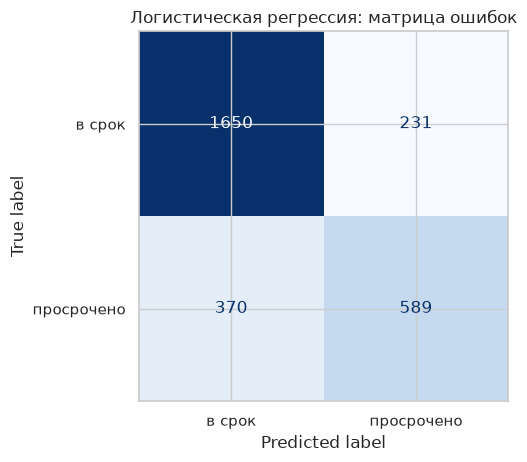

In [17]:
# из коробки
logreg = Pipeline([("pre", make_pre()), ("lr", LogisticRegression(max_iter=1000))])
logreg.fit(X_train, y_train)
res_logreg = evaluate("Логрег (из коробки)", logreg)

# с подбором C на кросс-валидации
logreg_cv = GridSearchCV(
    Pipeline([("pre", make_pre()), ("lr", LogisticRegression(max_iter=2000))]),
    {"lr__C": np.logspace(-2, 2, 9)},
    scoring="roc_auc", cv=StratifiedKFold(5, shuffle=True, random_state=RS), n_jobs=-1)
logreg_cv.fit(X_train, y_train)
print("Лучшее C:", round(logreg_cv.best_params_["lr__C"], 3))
res_logreg_cv = evaluate("Логрег (подбор C)", logreg_cv.best_estimator_)

for r in (res_logreg, res_logreg_cv):
    print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in r.items()})

# матрица ошибок лучшего логрега
cm = confusion_matrix(y_test, logreg_cv.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["в срок", "просрочено"]).plot(
    cmap="Blues", colorbar=False)
plt.title("Логистическая регрессия: матрица ошибок")
plt.show()

Качество логрега: ROC-AUC ≈ **0.85** — модель уверенно ранжирует поручения по риску. Подбор `C` практически не меняет качество (лучшее `C` ≈ 0.32, AUC тот же): регуляризация здесь ничего не добавляет. При пороге 0.5 recall ≈ **0.61** — ловится около 61 % просрочек. По матрице ошибок видно, где модель ошибается (справа внизу — пойманные просрочки, слева внизу — пропущенные). Recall можно поднять, снизив порог (см. выводы).

## 11. Модель 2 — kNN (метод k ближайших соседей)

**kNN** относит поручение к классу по большинству среди `k` самых похожих поручений в пространстве признаков («похожесть» = близость по евклидову расстоянию, поэтому масштабирование обязательно). Число соседей `k` подбираем на кросс-валидации по ROC-AUC. Замечание: при подборе по ROC-AUC кросс-валидация тяготеет к бо́льшим `k` (более гладкие вероятности), поэтому оптимум приходится на бо́льшие `k` (в нашем случае k ≈ 81); при этом дальнейший рост `k` качество на тесте не улучшает — kNN всё равно уступает логрегу.

In [18]:
knn = GridSearchCV(
    Pipeline([("pre", make_pre()), ("knn", KNeighborsClassifier())]),
    {"knn__n_neighbors": list(range(5, 122, 4))},
    scoring="roc_auc", cv=StratifiedKFold(5, shuffle=True, random_state=RS), n_jobs=-1)
knn.fit(X_train, y_train)
print("Лучшее k:", knn.best_params_["knn__n_neighbors"])
res_knn = evaluate("kNN (подбор k)", knn.best_estimator_)
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in res_knn.items()})

Лучшее k: 81
{'model': 'kNN (подбор k)', 'accuracy': 0.759, 'precision': 0.802, 'recall': 0.38, 'f1': 0.515, 'roc_auc': 0.822}


## 12. Сравнение моделей

Сводим метрики трёх честных моделей в одну таблицу и рисуем их ROC-кривые. Напомним приоритет: для поиска рискованных поручений важен **recall** (доля пойманных просрочек) и общее качество ранжирования **ROC-AUC**.

                     accuracy  precision  recall     f1  roc_auc
model                                                           
Логрег (из коробки)     0.788      0.717   0.614  0.662    0.847
Логрег (подбор C)       0.788      0.718   0.614  0.662    0.847
kNN (подбор k)          0.759      0.802   0.380  0.515    0.822


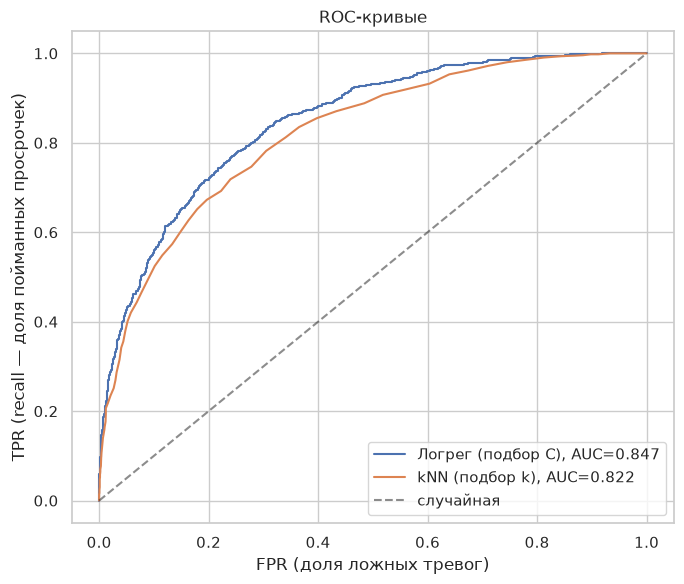

In [19]:
comparison = (pd.DataFrame([res_logreg, res_logreg_cv, res_knn])
              .set_index("model").round(3))
print(comparison.to_string())

plt.figure(figsize=(7, 6))
for name, est in [("Логрег (подбор C)", logreg_cv.best_estimator_),
                  ("kNN (подбор k)", knn.best_estimator_)]:
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}, AUC={roc_auc_score(y_test, proba):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.5, label="случайная")
plt.xlabel("FPR (доля ложных тревог)")
plt.ylabel("TPR (recall — доля пойманных просрочек)")
plt.title("ROC-кривые")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Логистическая регрессия лучше kNN.** У неё выше ROC-AUC (≈ 0.85 против ≈ 0.82) и, что важнее для задачи, заметно выше recall (≈ 0.61 против ≈ 0.38) — kNN при большом `k` осторожничает и пропускает больше половины просрочек. Плюс логрег интерпретируем. Дальше разбираем именно его коэффициенты.

## 12.5. Вклад признаков из историчности (аблация)

Главный тезис работы — что историчность (SCD2) *действительно* помогает прогнозу, а не просто хранится. Проверим это численно: обучим логистическую регрессию на нарастающих наборах признаков и сравним ROC-AUC на одном и том же тесте. Разница между строками — чистый вклад соответствующего признака «из историчности».

In [20]:
ablation = []
for name, feats in [
    ("структурные (только карточка)", feature_num),
    ("+ история исполнителя (exec_hist)", feature_num + ["exec_hist"]),
    ("+ нагрузка исполнителя (workload_at_t)", feature_num + ["workload_at_t"]),
    ("+ обе из историчности", feature_num + ["exec_hist", "workload_at_t"]),
]:
    pre = ColumnTransformer([("num", StandardScaler(), feats),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
    m = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000))])
    m.fit(train[feats + CAT], y_train)
    auc = roc_auc_score(y_test, m.predict_proba(test[feats + CAT])[:, 1])
    ablation.append({"набор признаков": name, "ROC-AUC": round(auc, 3)})
print(pd.DataFrame(ablation).to_string(index=False))

                       набор признаков  ROC-AUC
         структурные (только карточка)    0.691
     + история исполнителя (exec_hist)    0.799
+ нагрузка исполнителя (workload_at_t)    0.819
                 + обе из историчности    0.847


## 13. Интерпретация: что повышает риск просрочки

У логистической регрессии на **стандартизованных** признаках коэффициент показывает вклад признака в риск: знак «+» повышает вероятность просрочки, «−» понижает; величина — сила влияния. Строим топ-признаков по модулю коэффициента (коды типов заменяем на названия для читаемости).

*Оговорка:* числовые признаки стандартизованы, а one-hot типов — нет (масштаб 0/1), поэтому сравнивать модуль коэффициента типа напрямую с числовыми не вполне корректно — «важность» типов на графике несколько завышена. Знаки и качественные выводы при этом верны.

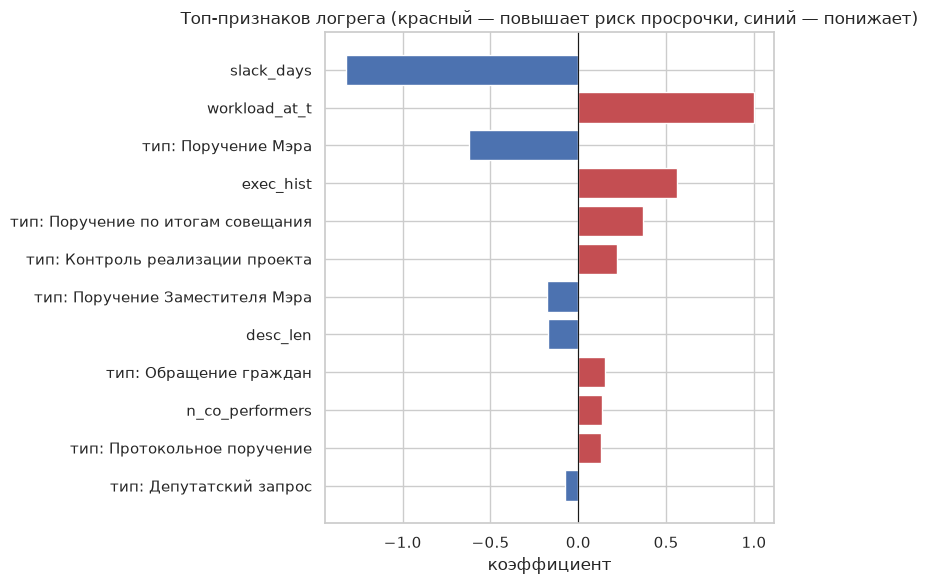

In [21]:
# карта type_bk -> название
type_names = read_sql("select elma_id::text as bk, name from control_order_types")
bk2name = dict(zip(type_names["bk"], type_names["name"]))

best = logreg_cv.best_estimator_
feat_names = best.named_steps["pre"].get_feature_names_out()
def pretty(n):
    n = n.split("__")[-1]
    for bk, nm in bk2name.items():
        n = n.replace("control_order_type_bk_" + bk, f"тип: {nm}")
    return n
coefs = pd.Series(best.named_steps["lr"].coef_[0],
                  index=[pretty(n) for n in feat_names])
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(8, 6))
colors = ["#c44e52" if c > 0 else "#4c72b0" for c in top.values]
plt.barh(range(len(top)), top.values, color=colors)
plt.yticks(range(len(top)), top.index)
plt.gca().invert_yaxis()
plt.axvline(0, color="k", lw=0.8)
plt.title("Топ-признаков логрега (красный — повышает риск просрочки, синий — понижает)")
plt.xlabel("коэффициент")
plt.tight_layout()
plt.show()

Читаем результат:
- **`slack_days` — сильнее всего снижает риск** (большой отрицательный коэффициент): чем больше запас времени до дедлайна, тем реже просрочка. Это главный и самый логичный драйвер.
- **`exec_hist` повышает риск**: исполнители с исторически высокой долей просрочек (посчитанной только по их прошлым поручениям) чаще срывают и новые.
- **`workload_at_t` повышает риск**: чем больше других поручений висит на исполнителе в момент постановки, тем выше вероятность просрочки — перегруженный исполнитель чаще не успевает. Это признак из историчности: без восстановления состояния на момент T его не посчитать.
- **`desc_len` слегка снижает риск**: хорошо описанные поручения выполняются аккуратнее.
- **`n_co_performers` повышает риск**: чем больше соисполнителей, тем сложнее координация.
- Отдельные **типы поручений** систематически рискованнее/безопаснее других.

Всё это — величины, известные уже в момент постановки, поэтому модель применима на практике.

## 14. Выводы

1. **Утечка данных показана численно.** Модель на полях-итогах даёт AUC = 1.0 — «слишком хорошо», потому что эти поля содержат ответ. Честная постановка требует их исключить; сборка «на момент T» из истории версий (SCD2) это обеспечивает by design, а инвариант («состояние на T не несёт исхода») мы проверили явно.
2. **Историчность используется, а не декларируется.** Из истории версий восстановлены два признака, которых нет в карточке поручения: **историческая дисциплина исполнителя** и его **нагрузка на момент T** (оба — строго по прошлому). Аблация (раздел 12.5) показывает их вклад: только структурные признаки дают ROC-AUC ≈ 0.69, добавление истории исполнителя → ≈ 0.80, добавление нагрузки → ещё выше, оба вместе → ≈ 0.85. То есть признаки из историчности поднимают качество с 0.69 до 0.85 — это главный результат работы.
3. **Лучшая модель — логистическая регрессия** (ROC-AUC ≈ 0.85, recall ≈ 0.61 — выше, чем у kNN, и она интерпретируема). kNN уступает и по AUC, и особенно по recall.
4. **Драйверы риска** содержательны: главный — малый запас времени до дедлайна; далее — историческая дисциплина исполнителя, его текущая загрузка, число соисполнителей, качество описания и тип поручения.
5. **Recall под задачу.** При пороге 0.5 ловится ~61% просрочек. Если цель — не пропустить риск, порог можно снизить: recall вырастет ценой большего числа ложных тревог (компромисс precision/recall). Порог выбирается под стоимость ошибок в конкретном процессе.
6. **Честные ограничения.** Данные синтетические (хоть и правдоподобные). Мы ограничились линейными моделями и kNN в рамках курса; нелинейные модели (деревья, градиентный бустинг) на этих признаках могли бы дать иной результат — отдельной проверки мы не делали, поэтому и не утверждаем ничего о «потолке» качества. Разбиение по времени, историческая дисциплина и нагрузка исполнителя посчитаны строго по прошлому, чтобы не занести утечку.

**Практический смысл:** уже в момент постановки поручения модель по объективным признакам отделяет группу повышенного риска — этого достаточно, чтобы заранее усилить контроль над «подозрительными» поручениями.